<a href="https://colab.research.google.com/github/shankarthanu/Repo1/blob/featureBranch1/colabtest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
import json
import prettytable
headers = {'Content-type': 'application/json'}
data = json.dumps({"seriesid": ['CUUR0000SA0','SUUR0000SA0'],"startyear":"2011", "endyear":"2014"})
p = requests.post('https://api.bls.gov/publicAPI/v2/timeseries/data/', data=data, headers=headers)
json_data = json.loads(p.text)
for series in json_data['Results']['series']:
    x=prettytable.PrettyTable(["series id","year","period","value","footnotes"])
    seriesId = series['seriesID']
    for item in series['data']:
        year = item['year']
        period = item['period']
        value = item['value']
        footnotes=""
        for footnote in item['footnotes']:
            if footnote:
                footnotes = footnotes + footnote['text'] + ','
        if 'M01' <= period <= 'M12':
            x.add_row([seriesId,year,period,value,footnotes[0:-1]])
    output = open(seriesId + '111.txt','w')
    output.write (x.get_string())
    output.close()

In [ ]:

print(json_data)

{'status': 'REQUEST_SUCCEEDED', 'responseTime': 102, 'message': [], 'Results': {'series': [{'seriesID': 'CUUR0000SA0', 'data': [{'year': '2014', 'period': 'M12', 'periodName': 'December', 'value': '234.812', 'footnotes': [{}]}, {'year': '2014', 'period': 'M11', 'periodName': 'November', 'value': '236.151', 'footnotes': [{}]}, {'year': '2014', 'period': 'M10', 'periodName': 'October', 'value': '237.433', 'footnotes': [{}]}, {'year': '2014', 'period': 'M09', 'periodName': 'September', 'value': '238.031', 'footnotes': [{}]}, {'year': '2014', 'period': 'M08', 'periodName': 'August', 'value': '237.852', 'footnotes': [{}]}, {'year': '2014', 'period': 'M07', 'periodName': 'July', 'value': '238.250', 'footnotes': [{}]}, {'year': '2014', 'period': 'M06', 'periodName': 'June', 'value': '238.343', 'footnotes': [{}]}, {'year': '2014', 'period': 'M05', 'periodName': 'May', 'value': '237.900', 'footnotes': [{}]}, {'year': '2014', 'period': 'M04', 'periodName': 'April', 'value': '237.072', 'footnotes

In [ ]:
print(json.dumps(json_data, indent=4))

{
    "status": "REQUEST_SUCCEEDED",
    "responseTime": 102,
    "message": [],
    "Results": {
        "series": [
            {
                "seriesID": "CUUR0000SA0",
                "data": [
                    {
                        "year": "2014",
                        "period": "M12",
                        "periodName": "December",
                        "value": "234.812",
                        "footnotes": [
                            {}
                        ]
                    },
                    {
                        "year": "2014",
                        "period": "M11",
                        "periodName": "November",
                        "value": "236.151",
                        "footnotes": [
                            {}
                        ]
                    },
                    {
                        "year": "2014",
                        "period": "M10",
                        "periodName": "October",
               

   year period periodName    value footnotes     seriesID
0  2014    M12   December  234.812      [{}]  CUUR0000SA0
1  2014    M11   November  236.151      [{}]  CUUR0000SA0
2  2014    M10    October  237.433      [{}]  CUUR0000SA0
3  2014    M09  September  238.031      [{}]  CUUR0000SA0
4  2014    M08     August  237.852      [{}]  CUUR0000SA0


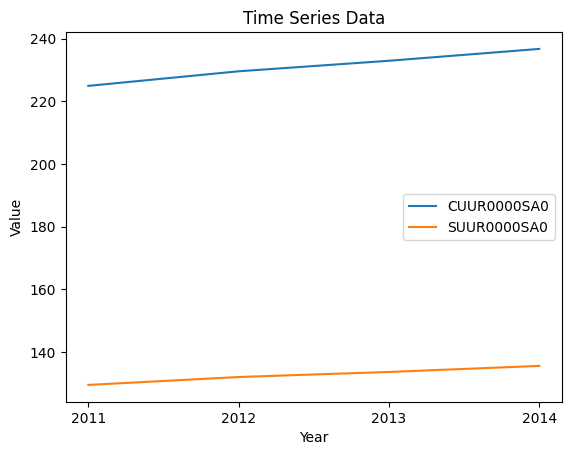

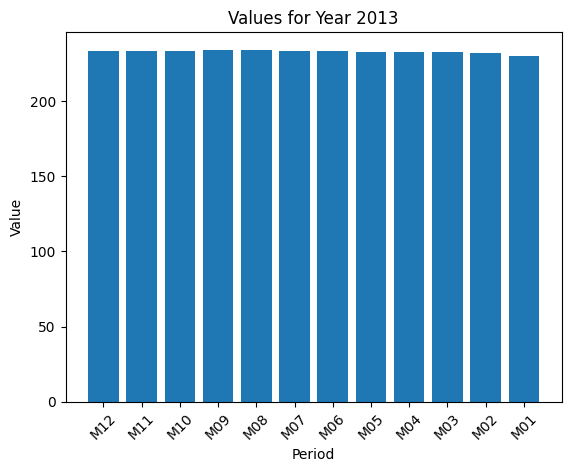

In [ ]:
import pandas as pd

# Assuming json_data is your JSON data
# Convert the JSON data to a pandas DataFrame
df = pd.json_normalize(json_data['Results']['series'], record_path=['data'],
                       meta=['seriesID'])

# Convert the 'value' column to numeric, handling errors
df['value'] = pd.to_numeric(df['value'], errors='coerce')

# Display the first few rows of the DataFrame
print(df.head())

# Now, let's explore some visualization options
# 1. Line Chart for Time Series Data
# You can create a line chart to visualize the 'value' over time for each 'seriesID'.

import matplotlib.pyplot as plt

# Group the data by 'seriesID' and 'year' and calculate the mean value
grouped_data = df.groupby(['seriesID', 'year'])['value'].mean().reset_index()

# Plot the line chart
for series_id in grouped_data['seriesID'].unique():
    series_data = grouped_data[grouped_data['seriesID'] == series_id]
    plt.plot(series_data['year'], series_data['value'], label=series_id)

plt.xlabel('Year')
plt.ylabel('Value')
plt.title('Time Series Data')
plt.legend()
plt.show()


# 2. Bar Chart for Comparing Values
# You can create a bar chart to compare the 'value' for different 'period' within a specific year.

# Filter the data for a specific year (e.g., 2013)
year_data = df[df['year'] == '2013']

# Create a bar chart
plt.bar(year_data['period'], year_data['value'])
plt.xlabel('Period')
plt.ylabel('Value')
plt.title('Values for Year 2013')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')